In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset load karo
df = pd.read_csv('WELFake_Dataset.csv')

# Basic info dekho
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:")
print(df['label'].value_counts())
print("\nFirst 3 rows:")
df.head(3)

Dataset shape: (72134, 4)

Columns: ['Unnamed: 0', 'title', 'text', 'label']

Class distribution:
label
1    37106
0    35028
Name: count, dtype: int64

First 3 rows:


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1


In [2]:
# Null values check karo
print("Null values:")
print(df.isnull().sum())

# Null rows drop karo
df = df.dropna()
print("\nAfter removing nulls:", df.shape)

# Title + Text combine karo (BERT ke liye)
df['combined'] = df['title'] + ' ' + df['text']

# Lowercase karo
df['combined'] = df['combined'].str.lower()

print("\nCombined column sample:")
print(df['combined'].iloc[0][:200])
print("\nData cleaning COMPLETE!")

Null values:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

After removing nulls: (71537, 4)

Combined column sample:
law enforcement on high alert following threats against cops and whites on 9-11by #blacklivesmatter and #fyf911 terrorists [video] no comment is expected from barack obama members of the #fyf911 or #f

Data cleaning COMPLETE!


C:\Users\rtktr\AppData\Local\Temp\ipykernel_7104\3593514139.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#E74C3C','#2ECC71'])


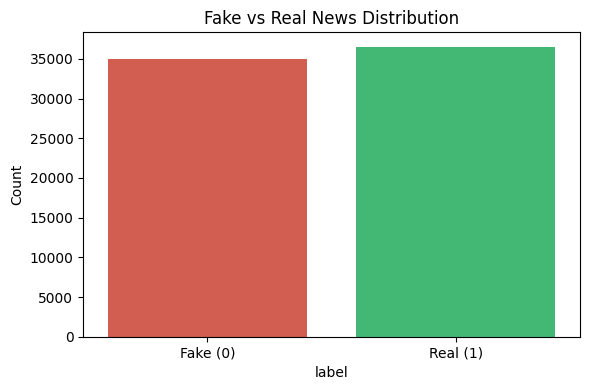

Graph save ho gaya!


In [3]:
# Class distribution graph
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['#E74C3C','#2ECC71'])
plt.title('Fake vs Real News Distribution')
plt.xticks([0,1], ['Fake (0)', 'Real (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()
print("Graph save ho gaya!")

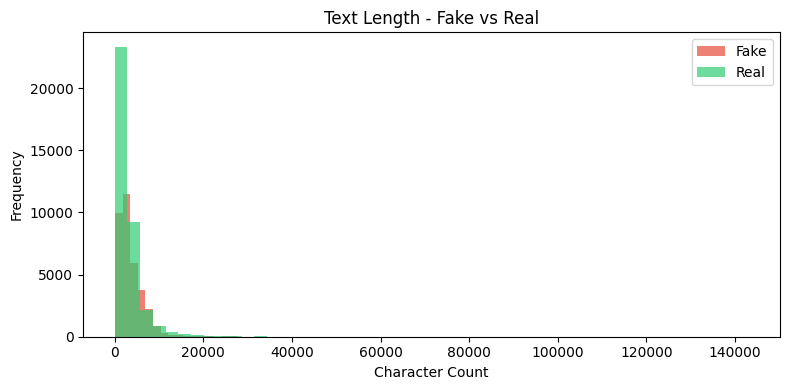

Average fake length: 3565.0
Average real length: 3184.0


In [4]:
# Text length distribution
df['text_length'] = df['combined'].str.len()

plt.figure(figsize=(8,4))
plt.hist(df[df['label']==0]['text_length'], bins=50, 
         alpha=0.7, color='#E74C3C', label='Fake')
plt.hist(df[df['label']==1]['text_length'], bins=50, 
         alpha=0.7, color='#2ECC71', label='Real')
plt.title('Text Length - Fake vs Real')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('text_length.png')
plt.show()
print("Average fake length:", df[df['label']==0]['text_length'].mean().round())
print("Average real length:", df[df['label']==1]['text_length'].mean().round())

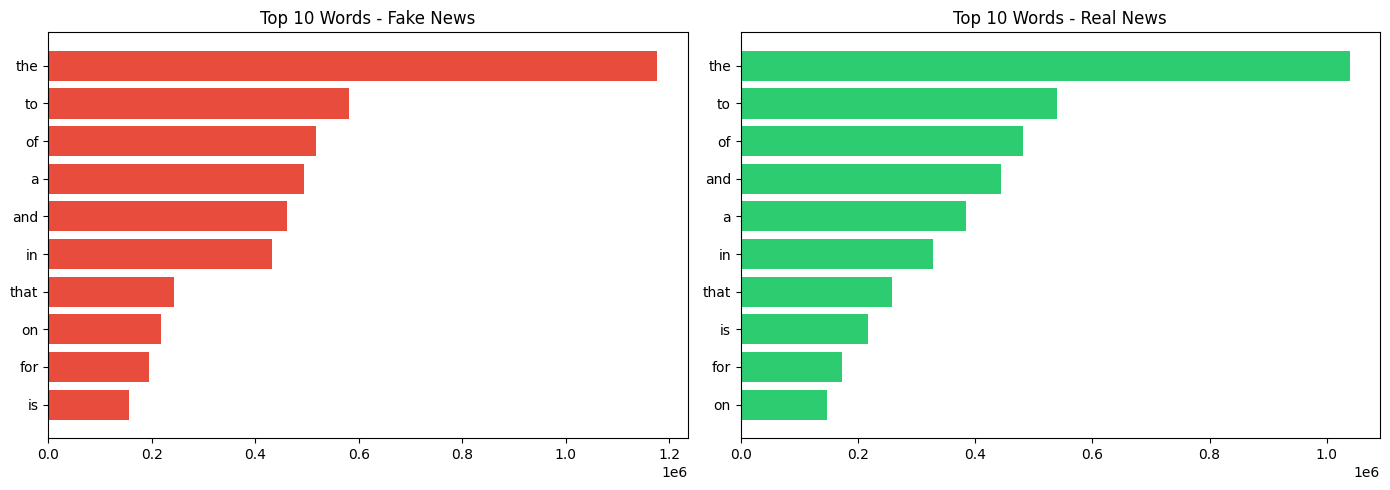

EDA COMPLETE!


In [5]:
# Top words in Fake vs Real news
from collections import Counter

# Fake news ke top words
fake_words = ' '.join(df[df['label']==0]['combined']).split()
fake_common = Counter(fake_words).most_common(10)

# Real news ke top words  
real_words = ' '.join(df[df['label']==1]['combined']).split()
real_common = Counter(real_words).most_common(10)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Fake
words1, counts1 = zip(*fake_common)
ax1.barh(words1, counts1, color='#E74C3C')
ax1.set_title('Top 10 Words - Fake News')
ax1.invert_yaxis()

# Real
words2, counts2 = zip(*real_common)
ax2.barh(words2, counts2, color='#2ECC71')
ax2.set_title('Top 10 Words - Real News')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('top_words.png')
plt.show()
print("EDA COMPLETE!")